In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [7]:
df = pd.read_csv('/content/PS_20174392719_1491204439457_log (1).csv')

Describing the data

In [8]:
df.head (5)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0.0,0.0


In [9]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,1.738330e+06,1.738330e+06,1.738329e+06,1.738329e+06,1.738329e+06,1.738329e+06,1.738329e+06,1738329.0
mean,7.244697e+01,1.626009e+05,8.595815e+05,8.808248e+05,9.950622e+05,1.117741e+06,1.060789e-03,0.0
std,5.789894e+01,2.697306e+05,2.924748e+06,2.960935e+06,2.306443e+06,2.405613e+06,3.255248e-02,0.0
min,1.000000e+00,6.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
25%,1.800000e+01,1.319678e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0
50%,4.200000e+01,7.917895e+04,1.511800e+04,0.000000e+00,1.365656e+05,2.288219e+05,0.000000e+00,0.0
75%,1.360000e+02,2.186782e+05,1.232930e+05,1.660498e+05,9.460123e+05,1.157310e+06,0.000000e+00,0.0
max,1.610000e+02,1.000000e+07,3.893942e+07,3.894623e+07,4.220740e+07,4.220740e+07,1.000000e+00,0.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1738330 entries, 0 to 1738329
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         float64
 10  isFlaggedFraud  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 145.9+ MB


In [11]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,1
oldbalanceOrg,1
newbalanceOrig,1
nameDest,1
oldbalanceDest,1
newbalanceDest,1
isFraud,1


Pre-Processing and Feature Engineering

In [12]:
df = df.drop(['nameOrig', 'nameDest'], axis=1)

In [13]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])


In [14]:
df['balanceOrigDiff'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDestDiff'] = df['newbalanceDest'] - df['oldbalanceDest']

In [15]:
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']

In [16]:
X = df.drop(['isFraud'], axis=1)
y = df['isFraud']


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


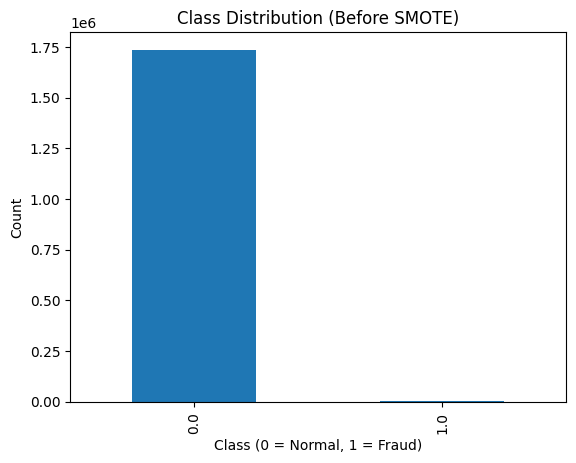

In [28]:
import matplotlib.pyplot as plt

plt.figure()
y.value_counts().plot(kind='bar')
plt.title("Class Distribution (Before SMOTE)")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

In [29]:
from imblearn.over_sampling import SMOTE
nan_indices = y_train.isna()
X_train = X_train[~nan_indices]
y_train = y_train[~nan_indices]
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

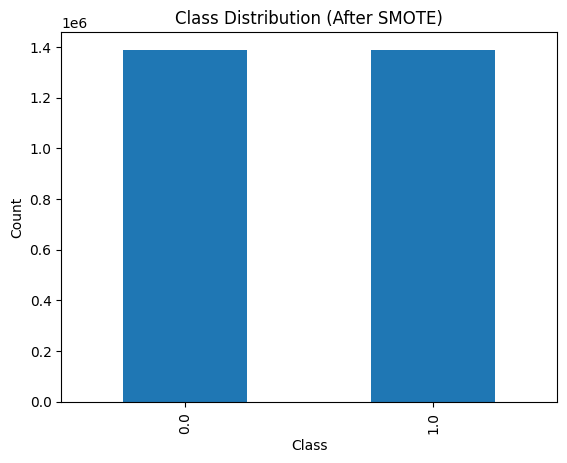

In [30]:
plt.figure()
pd.Series(y_train).value_counts().plot(kind='bar')
plt.title("Class Distribution (After SMOTE)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [19]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Models on which the dataset will be trained

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

In [21]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [36]:
import pandas as pd

def plot_feature_importance(model, X):
    importance = model.feature_importances_
    feature_names = pd.DataFrame(X).columns

    plt.figure()
    plt.barh(feature_names, importance)
    plt.title("Feature Importance")
    plt.xlabel("Importance Score")
    plt.show()

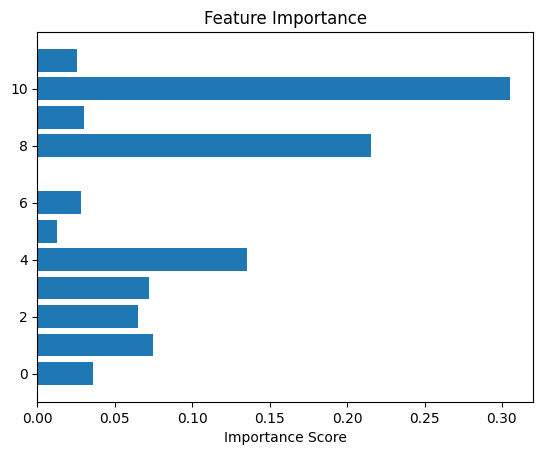

In [37]:
plot_feature_importance(rf, X_train)

In [22]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [23]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:43:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [24]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nROC-AUC Score:")
    print(roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

In [27]:
print("Random Forest Results")
evaluate_model(rf, X_test, y_test)

print("\nLogistic Regression Results")
evaluate_model(lr, X_test, y_test)

print("\nXGBoost Results")
evaluate_model(xgb, X_test, y_test)

Random Forest Results
Confusion Matrix:
[[347283     28]
 [     5    350]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    347311
         1.0       0.93      0.99      0.95       355

    accuracy                           1.00    347666
   macro avg       0.96      0.99      0.98    347666
weighted avg       1.00      1.00      1.00    347666


ROC-AUC Score:
0.9971193289806705

Logistic Regression Results
Confusion Matrix:
[[335461  11850]
 [    46    309]]

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98    347311
         1.0       0.03      0.87      0.05       355

    accuracy                           0.97    347666
   macro avg       0.51      0.92      0.52    347666
weighted avg       1.00      0.97      0.98    347666


ROC-AUC Score:
0.9762920118555919

XGBoost Results
Confusion Matrix:
[[347103    208]
 [     7    348]]



In [31]:
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model, X_test, y_test):
    cm = confusion_matrix(y_test, model.predict(X_test))

    plt.figure()
    plt.imshow(cm)
    plt.title("Confusion Matrix")
    plt.colorbar()

    plt.xticks([0,1], ["Normal","Fraud"])
    plt.yticks([0,1], ["Normal","Fraud"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center")

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

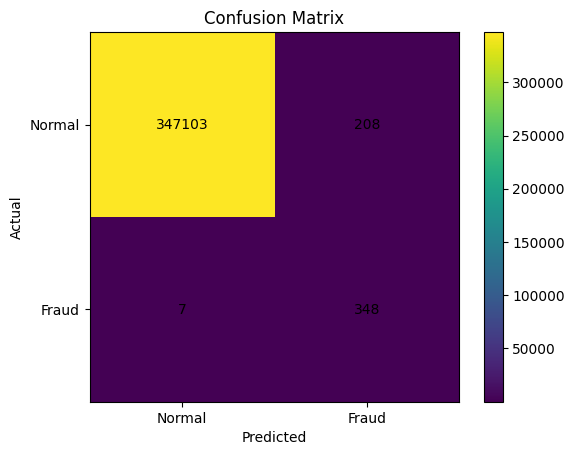

In [32]:
plot_confusion_matrix(xgb, X_test, y_test)

In [33]:
from sklearn.metrics import roc_curve, auc

def plot_roc(model, X_test, y_test):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1], [0,1], linestyle='--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

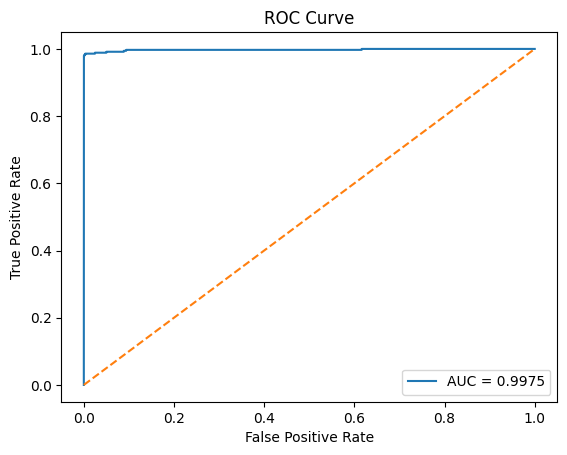

In [34]:
plot_roc(xgb, X_test, y_test)

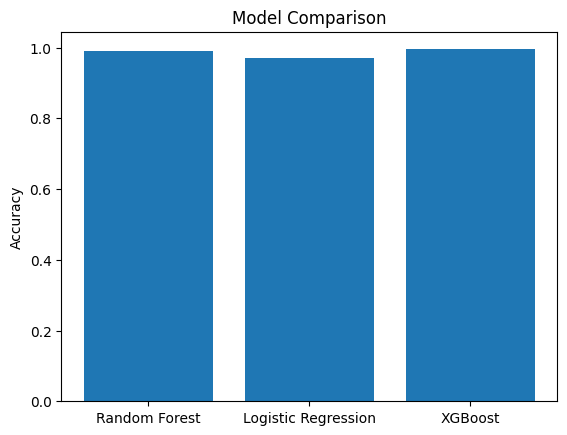

In [35]:
import numpy as np

models = ['Random Forest', 'Logistic Regression', 'XGBoost']
accuracy = [0.99, 0.97, 0.995]  # replace with your results

plt.figure()
plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

Explainable AI - SHAP

In [39]:
!pip install shap

In [40]:
import shap
import numpy as np

In [41]:
explainer = shap.Explainer(xgb)

In [42]:
X_sample = X_test[:1000]

shap_values = explainer(X_sample)

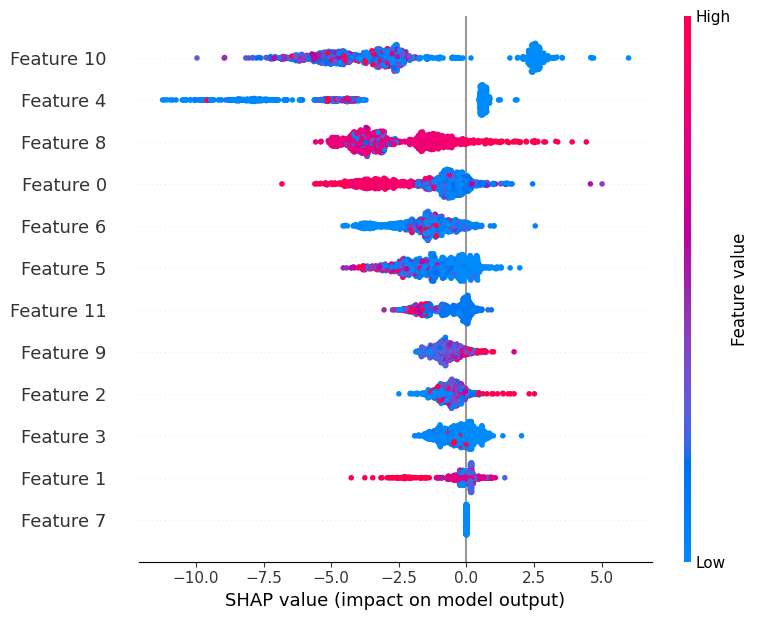

In [43]:
shap.summary_plot(shap_values, X_sample)

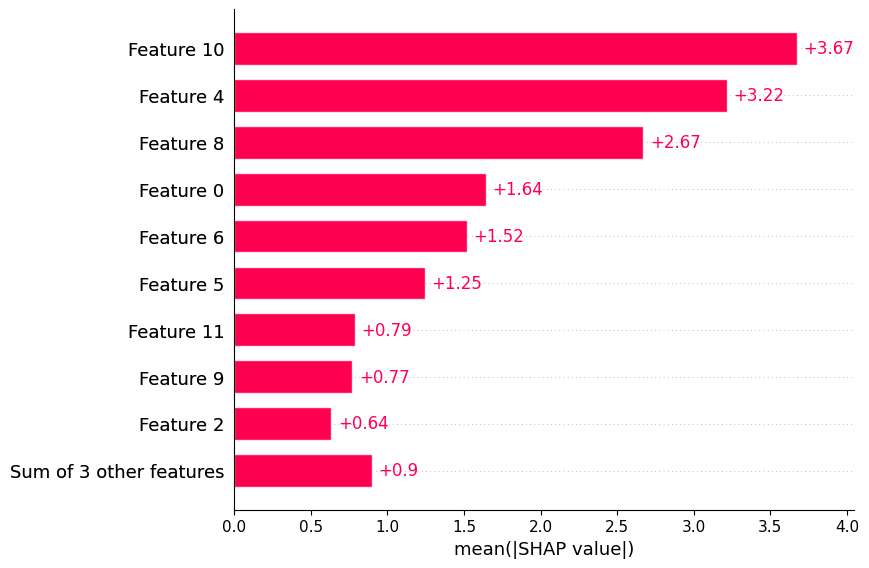

In [44]:
shap.plots.bar(shap_values)

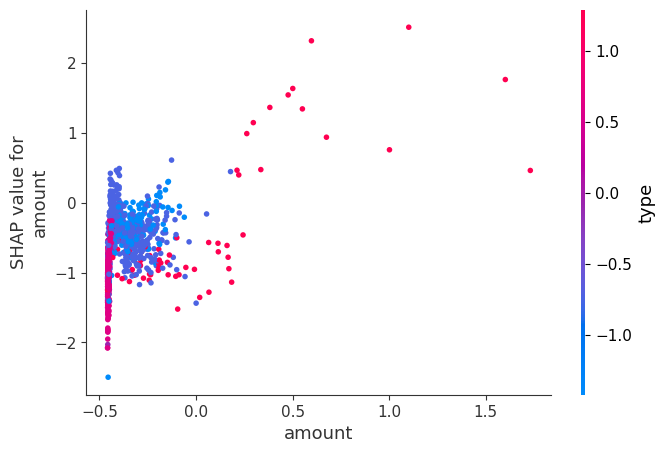

In [49]:
shap.dependence_plot("amount", shap_values.values, X_sample, feature_names=X.columns)

In [50]:
import pandas as pd

X_sample_df = pd.DataFrame(X_sample, columns=X.columns)
shap_values = explainer(X_sample_df)

In [51]:
import pickle

pickle.dump(xgb, open("model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))